In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [12]:
df = pd.read_csv('/workspaces/SML/SML /wdbc.data',header=None)

In [13]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
df_features = df.drop([0,1],axis=1)
df_target = df[1].map({'M':1,'B':0})

In [16]:
df_target.head()

0    1
1    1
2    1
3    1
4    1
Name: 1, dtype: int64

Dataset shape (569, 32)

Accuracy 0.916083916083916

Classifcation Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        89
           1       0.89      0.89      0.89        54

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143

Confusion Matrix:
 [[83  6]
 [ 6 48]]

Accuracy 0.951048951048951

Classifcation Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96        89
           1       0.93      0.94      0.94        54

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

Confusion Matrix:
 [[85  4]
 [ 3 51]]

Accuracy 0.951048951048951

Classifcation Report:

              precision    recall  f1-score   support

           0       0.97      0.96  

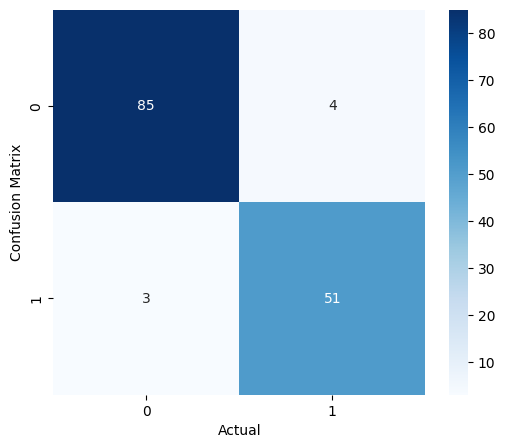

In [28]:
print("Dataset shape",df.shape)
X_train, X_test,y_train, y_test= train_test_split(df_features,df_target,test_size=0.25,random_state=42)
depth = [2,4,6,8,10]
for d in depth:
    classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth = d,
    random_state= 42
)
    classifier.fit(X_train,y_train)
    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    print("\nAccuracy",accuracy)
    print("\nClassifcation Report:\n")
    print(classification_report(y_test,y_pred))

    cm =confusion_matrix(y_test,y_pred)
    print("Confusion Matrix:\n",cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt = 'd',cmap = 'Blues')
plt.xlabel("Actual")
plt.ylabel("Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import accuracy_score, classification_report

# --- Training Results ---
y_train_pred = classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("--- TRAINING RESULTS ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print("\nTraining Classification Report:\n")
print(classification_report(y_train, y_train_pred))

print("-" * 30)

# --- Test Results ---
# y_pred is already calculated in your code for X_test
test_accuracy = accuracy_score(y_test, y_pred)

print("--- TEST RESULTS ---")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:\n")
print(classification_report(y_test, y_pred))

--- TRAINING RESULTS ---
Training Accuracy: 1.0000

Training Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       268
           1       1.00      1.00      1.00       158

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426

------------------------------
--- TEST RESULTS ---
Test Accuracy: 0.9510

Test Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96        89
           1       0.93      0.94      0.94        54

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

